# Lab 04: LU Factorization and Matrix Inverse

In the previous lab, we used Gaussian elimination to solve $A\mathbf{x} = \mathbf{b}$.  
**LU factorization** stores that same computation as a product of two triangular matrices:

$$A = LU$$

where $L$ is **lower triangular** (with 1s on the diagonal) and $U$ is **upper triangular**.  
Once $A = LU$ is known, solving for **any** right-hand side $\mathbf{b}$ requires only two cheap triangular solves.

## Learning Objectives

By the end of this session, you will be able to:
- Implement **Doolittle's algorithm** to compute $L$ and $U$ directly from $A$
- Use `scipy.linalg.lu` and interpret the permutation matrix $P$
- Solve $A\mathbf{x} = \mathbf{b}$ via **forward and backward substitution** on $L$ and $U$
- Explain why LU is especially efficient for **multiple right-hand sides**
- Apply **Cholesky factorization** to symmetric positive definite (SPD) matrices
- Compute matrix inverses using LU and understand when **not** to use them
- Interpret the **condition number** $\kappa(A)$ and diagnose ill-conditioned systems

## Session Outline

| # | Topic |  
|---|-------| 
| 1 | LU Factorization |  
| 2 | Multiple Right-Hand Sides |  
| 3 | Cholesky Factorization |  
| 4 | Matrix Inverse |  
| 5 | Condition Number and Ill-Conditioning |  

In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import time

---
## 1. LU Factorization

### 1.1 Connection to Gaussian Elimination

Gaussian elimination transforms $A$ into an upper triangular matrix $U$ by applying
**row operations**. Each operation subtracts a multiple of one row from a lower row;
the multipliers $\ell_{ik} = a_{ik}^{(k)} / a_{kk}^{(k)}$ turn out to be precisely
the entries of a lower triangular matrix $L$ (with 1s on the diagonal).

$$A = LU, \qquad
L = \begin{bmatrix} 1 & & & \\ \ell_{21} & 1 & & \\ \ell_{31} & \ell_{32} & 1 & \\ \vdots & & & \ddots \end{bmatrix},\quad
U = \begin{bmatrix} u_{11} & u_{12} & \cdots & u_{1n} \\ & u_{22} & \cdots & u_{2n} \\ & & \ddots & \vdots \\ & & & u_{nn} \end{bmatrix}$$

**Why bother?** Storing $L$ and $U$ lets us solve $A\mathbf{x} = \mathbf{b}$ for **new
right-hand sides** without repeating the expensive $O(n^3)$ factorization — only two
$O(n^2)$ triangular solves are needed.

| Step | Equation | Cost |
|------|----------|------|
| Factor (once) | $A = LU$ | $O(n^3/3)$ |
| Forward substitution | $L\mathbf{d} = \mathbf{b}$ | $O(n^2/2)$ |
| Backward substitution | $U\mathbf{x} = \mathbf{d}$ | $O(n^2/2)$ |

### 1.2 Doolittle's Algorithm

Doolittle's method computes $L$ and $U$ **directly** (no row operations needed).
With the convention $\ell_{ii} = 1$ for all $i$, matching $A = LU$ entry by entry gives:

For $k = 0, 1, \ldots, n-1$:

**Row $k$ of $U$** (for $j = k, k+1, \ldots, n-1$):
$$u_{kj} = a_{kj} - \sum_{m=0}^{k-1} \ell_{km}\, u_{mj}$$

**Column $k$ of $L$** (for $i = k+1, k+2, \ldots, n-1$):
$$\ell_{ik} = \frac{a_{ik} - \displaystyle\sum_{m=0}^{k-1} \ell_{im}\, u_{mk}}{u_{kk}}$$

Note: both sums are empty (zero) when $k = 0$, so $u_{0j} = a_{0j}$ and $\ell_{i0} = a_{i0}/u_{00}$.

### Step-by-Step Example ($3\times 3$)

Let
$$A = \begin{bmatrix} 2 & 1 & 1 \\ 4 & 3 & 3 \\ 8 & 7 & 9 \end{bmatrix}$$

**$k=0$:** Row 0 of $U$: $u_{00}=2,\ u_{01}=1,\ u_{02}=1$.  
Column 0 of $L$: $\ell_{10}=4/2=2,\ \ell_{20}=8/2=4$.

**$k=1$:** Row 1 of $U$: $u_{11}=3-2\cdot 1=1,\ u_{12}=3-2\cdot 1=1$.  
Column 1 of $L$: $\ell_{21}=(7-4\cdot 1)/1=3$.

**$k=2$:** Row 2 of $U$: $u_{22}=9-4\cdot 1-3\cdot 1=2$.

$$L = \begin{bmatrix} 1 & 0 & 0 \\ 2 & 1 & 0 \\ 4 & 3 & 1 \end{bmatrix},\quad
U = \begin{bmatrix} 2 & 1 & 1 \\ 0 & 1 & 1 \\ 0 & 0 & 2 \end{bmatrix}$$

In [ ]:
def lu_doolittle(A):
    """
    Compute the LU factorization A = L @ U using Doolittle's algorithm.
    L has 1s on the diagonal (unit lower triangular).
    No pivoting is performed.

    Parameters
    ----------
    A : (n, n) array-like

    Returns
    -------
    L : (n, n) ndarray  — unit lower triangular
    U : (n, n) ndarray  — upper triangular
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.eye(n)          # start with identity (diagonal = 1)
    U = np.zeros((n, n))

    for k in range(n):
        # ── Row k of U: U[k, j] = A[k, j] - sum_{m<k} L[k,m]*U[m,j]
        for j in range(k, n):
            # --- COMPLETE ---
            U[k, j] =                                     # A[k,j] - L[k,:k] @ U[:k,j]
            # --- COMPLETE ---

        # ── Column k of L: L[i, k] = (A[i,k] - sum_{m<k} L[i,m]*U[m,k]) / U[k,k]
        for i in range(k + 1, n):
            # --- COMPLETE ---
            L[i, k] =                                     # (A[i,k] - L[i,:k] @ U[:k,k]) / U[k,k]
            # --- COMPLETE ---

    return L, U

<!-- SOLUTION
U[k, j] = A[k, j] - L[k, :k] @ U[:k, j]
L[i, k] = (A[i, k] - L[i, :k] @ U[:k, k]) / U[k, k]
-->

In [13]:
# Verify on the 3x3 example traced above
A_test = np.array([[8, 7, 9],
                   [2, 1, 1],
                   [4, 3, 3]], dtype=float)

L, U = lu_doolittle(A_test)

print('L =\n', L)
print('U =\n', U)
print('LU =\n', L@U)
# print('\nSanity check  L @ U - A =\n', L @ U - A_test)

# Compare with scipy 
P, L_sc, U_sc = sc.linalg.lu(A_test)
print('L_sc =\n', L_sc)
print('U_sc =\n', U_sc)
print('L_scU_sc =\n', P@L_sc@U_sc)

L =
 [[1.         0.         0.        ]
 [0.25       1.         0.        ]
 [0.5        0.66666667 1.        ]]
U =
 [[ 8.          7.          9.        ]
 [ 0.         -0.75       -1.25      ]
 [ 0.          0.         -0.66666667]]
LU =
 [[8. 7. 9.]
 [2. 1. 1.]
 [4. 3. 3.]]
L_sc =
 [[1.         0.         0.        ]
 [0.25       1.         0.        ]
 [0.5        0.66666667 1.        ]]
U_sc =
 [[ 8.          7.          9.        ]
 [ 0.         -0.75       -1.25      ]
 [ 0.          0.         -0.66666667]]
L_scU_sc =
 [[8. 7. 9.]
 [2. 1. 1.]
 [4. 3. 3.]]


### 1.3 Using `scipy.linalg.lu` (with Permutation)

Without pivoting, LU factorization fails when a diagonal element is zero (or near zero).
In practice, **partial pivoting** is applied: before each elimination step, rows are
reordered to place the largest absolute value on the diagonal.  
This leads to the decomposition $PA = LU$, where $P$ is a **permutation matrix**.

```python
P, L, U = sc.linalg.lu(A)   # returns P, L, U such that A == P @ L @ U
```

> **Convention:** `scipy` returns $P$, $L$, $U$ satisfying $A = P\,L\,U$, which is
> equivalent to $P^T A = L U$ (since $P^{-1} = P^T$ for permutation matrices).

In [14]:
# Example: LU with partial pivoting via scipy
A = np.array([[ 3, -0.1, -0.2],
              [ 0.1,  7, -0.3],
              [ 0.3, -0.2, 10]], dtype=float)

P, L, U = sc.linalg.lu(A)

print('Permutation matrix P =\n', P)
print('\nLower triangular L =\n', np.round(L, 6))
print('\nUpper triangular U =\n', np.round(U, 6))
print('\nSanity check  P @ L @ U - A =\n', np.round(P @ L @ U - A, 12))

# When P = I, there was no row swapping
print('\nIdentity permutation (no row swaps):', np.allclose(P, np.eye(3)))

Permutation matrix P =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Lower triangular L =
 [[ 1.        0.        0.      ]
 [ 0.033333  1.        0.      ]
 [ 0.1      -0.02713   1.      ]]

Upper triangular U =
 [[ 3.       -0.1      -0.2     ]
 [ 0.        7.003333 -0.293333]
 [ 0.        0.       10.012042]]

Sanity check  P @ L @ U - A =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Identity permutation (no row swaps): True


### 1.4 Solving $A\mathbf{x} = \mathbf{b}$ via $L$ and $U$

With $A = LU$ (or $PA = LU$), the system $A\mathbf{x} = \mathbf{b}$ splits into two triangular systems:

**Step 1 — Forward substitution:** Solve $L\mathbf{d} = \mathbf{b}$ (or $\mathbf{b}' = P^T\mathbf{b}$ if pivoting was used)

$$d_0 = b_0, \qquad d_i = b_i - \sum_{j=0}^{i-1} \ell_{ij}\, d_j, \quad i = 1, \ldots, n-1$$

**Step 2 — Backward substitution:** Solve $U\mathbf{x} = \mathbf{d}$

$$x_{n-1} = \frac{d_{n-1}}{u_{n-1,n-1}}, \qquad
x_i = \frac{d_i - \displaystyle\sum_{j=i+1}^{n-1} u_{ij}\, x_j}{u_{ii}}, \quad i = n-2, \ldots, 0$$

In [ ]:
def forward_sub(L, b):
    """
    Solve L d = b by forward substitution.
    L must be unit lower triangular (diagonal = 1).

    Returns
    -------
    d : (n,) ndarray
    """
    n = len(b)
    d = np.zeros(n)
    for i in range(n):
        # --- COMPLETE ---
        d[i] =                                           # b[i] - L[i, :i] @ d[:i]
        # --- COMPLETE ---
    return d


def backward_sub(U, d):
    """
    Solve U x = d by backward substitution.
    U must be upper triangular.

    Returns
    -------
    x : (n,) ndarray
    """
    n = len(d)
    x = np.zeros(n)
    x[-1] = d[-1] / U[-1, -1]
    for i in range(n - 2, -1, -1):
        # --- COMPLETE ---
        x[i] =                                           # (d[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
        # --- COMPLETE ---
    return x


def lu_solve(A, b):
    """Solve Ax = b using scipy's LU (with pivoting) + triangular substitutions."""
    P, L, U = sc.linalg.lu(A)
    b_perm = P.T @ b          # apply permutation: P^T b
    d = forward_sub(L, b_perm)
    x = backward_sub(U, d)
    return x

<!-- SOLUTION
d[i] = b[i] - L[i, :i] @ d[:i]
x[i] = (d[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
-->

In [16]:
# Test on a 3x3 system with known solution
A_sys = np.array([[ 3, -0.1, -0.2],
                  [ 0.1,  7, -0.3],
                  [ 0.3, -0.2, 10]], dtype=float)
b_sys = np.array([7.85, -19.3, 71.4])

x_lu    = lu_solve(A_sys, b_sys)
x_ref   = np.linalg.solve(A_sys, b_sys)

print('Solution via LU solve :', np.round(x_lu, 6))
print('Solution via np.linalg:', np.round(x_ref, 6))
print('Max difference        :', np.max(np.abs(x_lu - x_ref)))
print('Residual ||Ax - b||   :', np.linalg.norm(A_sys @ x_lu - b_sys))

Solution via LU solve : [ 3.  -2.5  7. ]
Solution via np.linalg: [ 3.  -2.5  7. ]
Max difference        : 8.881784197001252e-16
Residual ||Ax - b||   : 1.4210854715202004e-14


### 1.5 Engineering Example: Thermal Resistor Network

Four nodes (1–4) are connected by thermal resistors. Nodes 1 and 4 are fixed at
$T_1 = 100^\circ\text{C}$ and $T_4 = 20^\circ\text{C}$. Heat sources inject
$Q_2 = 50\text{W}$ and $Q_3 = 30\text{W}$ at interior nodes 2 and 3.

```
 T1=100°C ──[R12=1]── Node2 ──[R23=2]── Node3 ──[R34=1]── T4=20°C
                        |                  |
                       Q2=50W            Q3=30W
                        |                  |
                       [R20=4]           [R30=2]
                        |                  |
                       GND(0°C)          GND(0°C)
```

Energy balance at each interior node (conductance $= 1/R$):
$$\left(\frac{1}{R_{12}} + \frac{1}{R_{23}} + \frac{1}{R_{20}}\right)T_2
- \frac{1}{R_{23}}T_3 = Q_2 + \frac{T_1}{R_{12}}$$
$$- \frac{1}{R_{23}}T_2 + \left(\frac{1}{R_{23}} + \frac{1}{R_{34}} + \frac{1}{R_{30}}\right)T_3
= Q_3 + \frac{T_4}{R_{34}}$$

In [17]:
# Thermal resistances (°C/W)
R12, R23, R34 = 1.0, 2.0, 1.0
R20, R30      = 4.0, 2.0
T1, T4        = 100.0, 20.0
Q2, Q3        = 50.0, 30.0

# Conductances (W/°C)
g12, g23, g34 = 1/R12, 1/R23, 1/R34
g20, g30      = 1/R20, 1/R30

# Assemble 2x2 system [K]{T} = {f}
K = np.array([
    [g12 + g23 + g20, -g23          ],
    [-g23,             g23 + g34 + g30]
])
f = np.array([
    Q2 + g12 * T1,
    Q3 + g34 * T4
])

print('Conductance matrix K =\n', K)
print('\nRight-hand side f =', f)

# Solve using our lu_solve
T_interior = lu_solve(K, f)
T2, T3 = T_interior
print(f'\nNode temperatures:')
print(f'  T1 = {T1:.2f} °C  (fixed)')
print(f'  T2 = {T2:.4f} °C')
print(f'  T3 = {T3:.4f} °C')
print(f'  T4 = {T4:.2f} °C  (fixed)')

# Verify energy balance at node 2: net heat out = Q2
q12_out = g12 * (T2 - T1)
q23_out = g23 * (T2 - T3)
q20_out = g20 * T2
print(f'\nEnergy balance at node 2 (should = 0): {Q2 + q12_out + q23_out + q20_out:.6f} W')

Conductance matrix K =
 [[ 1.75 -0.5 ]
 [-0.5   2.  ]]

Right-hand side f = [150.  50.]

Node temperatures:
  T1 = 100.00 °C  (fixed)
  T2 = 100.0000 °C
  T3 = 50.0000 °C
  T4 = 20.00 °C  (fixed)

Energy balance at node 2 (should = 0): 100.000000 W


---
## 2. Multiple Right-Hand Sides: Efficiency of LU

### 2.1 Why LU Shines with Multiple RHS

Suppose we need to solve $A\mathbf{x}_1 = \mathbf{b}_1,\; A\mathbf{x}_2 = \mathbf{b}_2,\;
\ldots,\; A\mathbf{x}_m = \mathbf{b}_m$ — the **same** matrix $A$ with $m$ different
right-hand sides.

| Approach | Cost |
|----------|------|
| Gaussian elimination per system | $m \times O(n^3/3)$ |
| **LU once, triangular solves** | $O(n^3/3) + m \times O(n^2)$ |

For $m = 100$ and $n = 200$: Gauss costs $\approx 100 \times 2.7\times10^6$ ops,
while LU + triangular costs $\approx 2.7\times10^6 + 100 \times 40{,}000$ ops
— roughly **25$\times$ faster**.

The same idea underlies computing the matrix inverse (Section 4): solving $AX = I$
with $n$ right-hand sides (the columns of the identity).

In [18]:
# Timing comparison: repeated Gauss vs LU-once
np.random.seed(0)
n = 200
m_values = [1, 5, 20, 50, 100]

A_rand = np.random.randn(n, n) + n * np.eye(n)   # diagonally dominant
B_rand = np.random.randn(n, max(m_values))

times_gauss = []
times_lu    = []

for m in m_values:
    # Method 1: np.linalg.solve for each column (internally does LU each time)
    t0 = time.perf_counter()
    for j in range(m):
        np.linalg.solve(A_rand, B_rand[:, j])
    times_gauss.append(time.perf_counter() - t0)

    # Method 2: factor once, then triangular solves
    t0 = time.perf_counter()
    lu_obj = sc.linalg.lu_factor(A_rand)           # stores LU in compact form
    for j in range(m):
        sc.linalg.lu_solve(lu_obj, B_rand[:, j])   # O(n^2) each
    times_lu.append(time.perf_counter() - t0)

print(f'{"m":>5}  {"Gauss×m (s)":>14}  {"LU+solves (s)":>14}  {"Speedup":>10}')
print('-' * 50)
for i, m in enumerate(m_values):
    sp = times_gauss[i] / times_lu[i]
    print(f'{m:>5}  {times_gauss[i]:>14.4f}  {times_lu[i]:>14.4f}  {sp:>10.1f}x')

    m     Gauss×m (s)   LU+solves (s)     Speedup
--------------------------------------------------
    1          0.0043          0.0071         0.6x
    5          0.0009          0.0004         2.1x
   20          0.0032          0.0009         3.5x
   50          0.0077          0.0017         4.5x
  100          0.0154          0.0031         5.0x


### 2.2 Application: Spring-Mass System Under Multiple Load Cases

Consider the three-mass spring system from Lab 03:

$$K = \begin{bmatrix} k_1+k_2 & -k_2 & 0 \\ -k_2 & k_2+k_3 & -k_3 \\ 0 & -k_3 & k_3+k_4 \end{bmatrix}$$

We want to find displacements under **three different load cases**
(gravity, wind, and combined loading) without refactoring $K$ each time.

Use `scipy.linalg.lu_factor` and `scipy.linalg.lu_solve` to factor once
and solve for all three load cases.

In [ ]:
# Spring constants (N/m)
k1, k2, k3, k4 = 40.0, 30.0, 20.0, 10.0

K_spring = np.array([
    [k1+k2,   -k2,      0],
    [  -k2, k2+k3,    -k3],
    [    0,   -k3,  k3+k4]
])

# Three load cases (N): gravity, wind, combined
F_gravity  = np.array([10.0, 10.0, 10.0])
F_wind     = np.array([50.0, 20.0,  0.0])
F_combined = F_gravity + F_wind

# --- COMPLETE: factor K once and solve for all three load cases ---
lu_K = sc.linalg.lu_factor(K_spring)                # factor K

x_gravity  =                                         # sc.linalg.lu_solve(lu_K, F_gravity)
x_wind     =                                         # sc.linalg.lu_solve(lu_K, F_wind)
x_combined =                                         # sc.linalg.lu_solve(lu_K, F_combined)
# --- COMPLETE ---

labels = ['Mass 1', 'Mass 2', 'Mass 3']
cases  = [('Gravity', x_gravity), ('Wind', x_wind), ('Combined', x_combined)]

print(f'{"Load Case":<12}  {"x1 (m)":>10}  {"x2 (m)":>10}  {"x3 (m)":>10}')
print('-' * 48)
for name, x in cases:
    print(f'{name:<12}  {x[0]:>10.5f}  {x[1]:>10.5f}  {x[2]:>10.5f}')

# Verify superposition: x_combined should equal x_gravity + x_wind
print(f'\nSuperposition check ||x_comb - (x_grav + x_wind)||: '
      f'{np.linalg.norm(x_combined - (x_gravity + x_wind)):.2e}')

Load Case         x1 (m)      x2 (m)      x3 (m)
------------------------------------------------
Gravity          0.52000     0.88000     0.92000
Wind             1.46000     1.74000     1.16000
Combined         1.98000     2.62000     2.08000

Superposition check ||x_comb - (x_grav + x_wind)||: 4.97e-16


<!-- SOLUTION
x_gravity  = sc.linalg.lu_solve(lu_K, F_gravity)
x_wind     = sc.linalg.lu_solve(lu_K, F_wind)
x_combined = sc.linalg.lu_solve(lu_K, F_combined)
-->

---
## 3. Cholesky Factorization

### 3.1 Symmetric Positive Definite (SPD) Matrices

A matrix $A$ is **symmetric positive definite** (SPD) if:
1. $A = A^T$ (symmetric)
2. $\mathbf{v}^T A \mathbf{v} > 0$ for all nonzero vectors $\mathbf{v}$ (positive definite)

Equivalent conditions:
- All **eigenvalues** are positive
- All **leading principal minors** (top-left submatrix determinants) are positive

SPD matrices arise naturally from:
- **Stiffness matrices** in structural mechanics ($K\mathbf{x} = \mathbf{f}$)
- **Normal equations** in least squares ($A^T A$)
- **Covariance matrices** in statistics

### 3.2 Cholesky: $A = LL^T$

For an SPD matrix, Cholesky factorization gives $A = LL^T$ where $L$ is a
lower triangular matrix with **positive diagonal entries**. Compared to general LU:

| Property | LU | Cholesky |
|----------|----|----------|
| Applicable to | Any (nonsingular) | SPD only |
| Factorization cost | $\approx n^3/3$ ops | $\approx n^3/6$ ops |
| Storage | Two matrices $L$, $U$ | One matrix $L$ |
| Numerical stability | Requires pivoting | Unconditionally stable |

**The Cholesky formula** (column by column, $k = 0, \ldots, n-1$):
$$\ell_{kk} = \sqrt{a_{kk} - \sum_{m=0}^{k-1} \ell_{km}^2}$$
$$\ell_{ik} = \frac{a_{ik} - \displaystyle\sum_{m=0}^{k-1} \ell_{im}\,\ell_{km}}{\ell_{kk}}, \quad i > k$$

In [20]:
# Check SPD properties
def is_spd(A):
    """Return True if A is symmetric positive definite."""
    if not np.allclose(A, A.T):
        return False
    eigenvalues = np.linalg.eigvalsh(A)
    return bool(np.all(eigenvalues > 0))

# Classic example: A = [[4,2],[2,3]]
A_spd = np.array([[4.0, 2.0], [2.0, 3.0]])
A_not = np.array([[4.0, 2.0], [2.0, 1.0]])   # not SPD (det=0)

print('A_spd is SPD:', is_spd(A_spd))
print('A_not is SPD:', is_spd(A_not))

# Cholesky with scipy (lower=True returns L such that A = L L^T)
L_chol = sc.linalg.cholesky(A_spd, lower=True)
print('\nCholesky factor L =\n', L_chol)
print('Sanity check L @ L.T - A =\n', L_chol @ L_chol.T - A_spd)

# 3x3 SPD example from the lecture notes
A_spd3 = np.array([[4, 12, -16],
                   [12, 37, -43],
                   [-16, -43, 98]], dtype=float)
print('\n3x3 SPD matrix:')
print('Is SPD:', is_spd(A_spd3))
L3 = sc.linalg.cholesky(A_spd3, lower=True)
print('L =\n', L3)

A_spd is SPD: True
A_not is SPD: False

Cholesky factor L =
 [[2.         0.        ]
 [1.         1.41421356]]
Sanity check L @ L.T - A =
 [[0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 4.4408921e-16]]

3x3 SPD matrix:
Is SPD: True
L =
 [[ 2.  0.  0.]
 [ 6.  1.  0.]
 [-8.  5.  3.]]


In [ ]:
def cholesky_solve(A, b):
    """
    Solve A x = b for an SPD matrix A using Cholesky factorization.

    Algorithm:
      1. Factor: A = L L^T
      2. Forward sub: L d = b
      3. Backward sub: L^T x = d

    Returns
    -------
    x : (n,) ndarray
    """
    # Step 1: Cholesky factorization
    L = sc.linalg.cholesky(A, lower=True)

    # Step 2: Forward substitution  L d = b
    # --- COMPLETE: use forward_sub defined in Section 1 ---
    d =                                                  # forward_sub(L, b)
    # --- COMPLETE ---

    # Step 3: Backward substitution  L^T x = d
    # --- COMPLETE: note that L^T is upper triangular ---
    x =                                                  # backward_sub(L.T, d)
    # --- COMPLETE ---

    return x

<!-- SOLUTION
d = forward_sub(L, b)
x = backward_sub(L.T, d)
-->

In [22]:
# Application: FEM spring network with SPD stiffness matrix
# 4-node bar element: K x = f, where K is SPD
K_fem = np.array([
    [ 2, -1,  0,  0],
    [-1,  2, -1,  0],
    [ 0, -1,  2, -1],
    [ 0,  0, -1,  1]
], dtype=float) * 1e4   # stiffness in N/m

f_ext = np.array([0.0, 0.0, 500.0, 1000.0])   # external forces in N

print('Is K_fem SPD?', is_spd(K_fem))

x_chol = cholesky_solve(K_fem, f_ext)
x_ref  = np.linalg.solve(K_fem, f_ext)

print('\nDisplacements (m):')
for i, xi in enumerate(x_chol):
    print(f'  x{i+1} = {xi*1000:.4f} mm')
print('\nMax error vs np.linalg.solve:', np.max(np.abs(x_chol - x_ref)))

# Efficiency: Cholesky vs LU for SPD systems
n = 500
# Build a large SPD matrix: A = R^T R for random R
R = np.random.randn(n, n)
A_large = R.T @ R + n * np.eye(n)
b_large = np.random.randn(n)

t0 = time.perf_counter(); sc.linalg.solve(A_large, b_large, assume_a='pos'); t_chol = time.perf_counter() - t0
t0 = time.perf_counter(); np.linalg.solve(A_large, b_large);                 t_lu   = time.perf_counter() - t0

print(f'\nSolve time (n={n}):  Cholesky = {t_chol:.4f}s,  LU = {t_lu:.4f}s,  speedup = {t_lu/t_chol:.1f}x')

Is K_fem SPD? True

Displacements (m):
  x1 = 222949.7266 mm
  x2 = 445899.4532 mm
  x3 = 668849.1799 mm
  x4 = 886025.4038 mm

Max error vs np.linalg.solve: 885.4754037844386

Solve time (n=500):  Cholesky = 0.0070s,  LU = 0.0016s,  speedup = 0.2x


---
## 4. Matrix Inverse

### 4.1 Definition and Properties

The **inverse** of a square matrix $A$ (if it exists) is the unique matrix $A^{-1}$ such that:
$$A A^{-1} = A^{-1} A = I$$

$A^{-1}$ exists if and only if $A$ is **nonsingular** ($\det(A) \neq 0$, i.e., no zero eigenvalues).

**Useful identities:**

| Identity | Formula |
|----------|---------|
| Inverse of product | $(AB)^{-1} = B^{-1} A^{-1}$ |
| Inverse of transpose | $(A^T)^{-1} = (A^{-1})^T$ |
| $2\times 2$ formula | $\begin{bmatrix}a&b\\c&d\end{bmatrix}^{-1} = \frac{1}{ad-bc}\begin{bmatrix}d&-b\\-c&a\end{bmatrix}$ |

### 4.2 Computing $A^{-1}$ via LU

Since $A X = I$ with $X = A^{-1}$, we can find $A^{-1}$ by solving $n$ systems:
$$A \mathbf{x}_j = \mathbf{e}_j, \quad j = 0, 1, \ldots, n-1$$
where $\mathbf{e}_j$ is the $j$-th column of the identity matrix.

**Algorithm:**
1. Factor $A = LU$ once: $O(n^3/3)$
2. For each $j = 0, \ldots, n-1$: solve $LU\mathbf{x}_j = \mathbf{e}_j$: $O(n^2)$ per column
3. Assemble $A^{-1} = [\mathbf{x}_0 \mid \mathbf{x}_1 \mid \cdots \mid \mathbf{x}_{n-1}]$

Total: $O(n^3/3 + n^3) = O(n^3)$

In [ ]:
def lu_inverse(A):
    """
    Compute A^{-1} by solving A X = I column by column using LU factorization.

    Returns
    -------
    A_inv : (n, n) ndarray
    """
    n = A.shape[0]
    I = np.eye(n)

    # Factor once
    lu_obj = sc.linalg.lu_factor(A)

    # --- COMPLETE: solve A x_j = e_j for each column j of I ---
    A_inv = np.zeros((n, n))
    for j in range(n):
        A_inv[:, j] =                                    # sc.linalg.lu_solve(lu_obj, I[:, j])
    # --- COMPLETE ---

    return A_inv

<!-- SOLUTION
A_inv[:, j] = sc.linalg.lu_solve(lu_obj, I[:, j])
-->

In [25]:
# Test lu_inverse
A_inv_lu  = lu_inverse(A_sys)
A_inv_ref = np.linalg.inv(A_sys)

print('A^{-1} via lu_inverse =\n', np.round(A_inv_lu, 6))
print('\nA^{-1} via np.linalg.inv =\n', np.round(A_inv_ref, 6))
print('\nMax error:', np.max(np.abs(A_inv_lu - A_inv_ref)))
print('Sanity check  A @ A_inv - I  max =', np.max(np.abs(A_sys @ A_inv_lu - np.eye(3))))

# Singular matrix — inverse does not exist
A_sing = np.array([[1.0, 2.0], [2.0, 4.0]])   # rank 1: row 2 = 2 * row 1
print('\nDeterminant of singular matrix:', np.linalg.det(A_sing))
try:
    np.linalg.inv(A_sing)
except np.linalg.LinAlgError as e:
    print('Error:', e)

A^{-1} via lu_inverse =
 [[ 0.332489  0.004944  0.006798]
 [-0.005182  0.142903  0.004183]
 [-0.010078  0.00271   0.09988 ]]

A^{-1} via np.linalg.inv =
 [[ 0.332489  0.004944  0.006798]
 [-0.005182  0.142903  0.004183]
 [-0.010078  0.00271   0.09988 ]]

Max error: 0.0
Sanity check  A @ A_inv - I  max = 2.220446049250313e-16

Determinant of singular matrix: 0.0
Error: Singular matrix


### 4.3 The Golden Rule: Solve, Don't Invert

Although $A^{-1}$ exists and can be computed, in practice you should **almost never
form it explicitly**. The reason:

- Computing $A^{-1}$ costs $\approx 3\times$ more than a single LU factorization
- Then using it: $\mathbf{x} = A^{-1}\mathbf{b}$ requires $n^2$ multiplications — same as `linalg.solve`
- But the explicit inverse accumulates **more floating-point errors**

> **Rule of thumb:** Replace $A^{-1}\mathbf{b}$ with `np.linalg.solve(A, b)` whenever possible.

**Exception:** Sensitivity analysis. If you need to see how $\mathbf{x}$ changes when
$\mathbf{b}$ changes — i.e., $\Delta\mathbf{x} = A^{-1}\Delta\mathbf{b}$ for many
small perturbations — forming $A^{-1}$ once and using matrix-vector products may
be justified.

In [26]:
# Demonstrate: solve is faster and more accurate than explicit inverse
n = 300
rng = np.random.default_rng(42)
A_timing = rng.standard_normal((n, n)) + n * np.eye(n)
b_timing = rng.standard_normal(n)

# Method 1: form inverse explicitly, then multiply
t0 = time.perf_counter()
A_inv_t = np.linalg.inv(A_timing)
x_inv   = A_inv_t @ b_timing
t_inv   = time.perf_counter() - t0

# Method 2: solve directly
t0 = time.perf_counter()
x_solve = np.linalg.solve(A_timing, b_timing)
t_solve = time.perf_counter() - t0

print(f'Method          Time (s)   ||Ax - b||')
print(f'inv + multiply  {t_inv:.4f}     {np.linalg.norm(A_timing @ x_inv - b_timing):.2e}')
print(f'linalg.solve    {t_solve:.4f}     {np.linalg.norm(A_timing @ x_solve - b_timing):.2e}')
print(f'\nSpeedup: {t_inv/t_solve:.1f}x   (solve is faster AND more accurate)')

Method          Time (s)   ||Ax - b||
inv + multiply  0.0018     1.59e-14
linalg.solve    0.0006     1.58e-14

Speedup: 3.2x   (solve is faster AND more accurate)


---
## 5. Condition Number and Ill-Conditioning

### 5.1 Definition and Interpretation

The **condition number** of a matrix $A$ is:
$$\kappa(A) = \|A\|\,\|A^{-1}\|$$

It measures how much a small perturbation $\delta\mathbf{b}$ in the right-hand side
amplifies the error $\delta\mathbf{x}$ in the solution:

$$\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|} \leq \kappa(A)\,\frac{\|\delta\mathbf{b}\|}{\|\mathbf{b}\|}$$

| $\kappa(A)$ | Interpretation |
|-------------|----------------|
| $\approx 1$ | Well-conditioned; full floating-point accuracy |
| $10^6$ | Solution may lose $\sim$6 significant digits |
| $\sim 1/\varepsilon_{\text{mach}} \approx 10^{16}$ | Effectively singular; solution unreliable |

**Rule of thumb:** If $\kappa(A) \approx 10^k$, expect to lose $\approx k$ significant digits.

### 5.2 Computing the Condition Number

```python
np.linalg.cond(A)       # 2-norm condition number (default)
np.linalg.cond(A, 1)    # 1-norm (max column sum)
np.linalg.cond(A, np.inf)  # infinity-norm (max row sum)
```

The **2-norm condition number** equals the ratio of largest to smallest singular value:
$\kappa_2(A) = \sigma_{\max} / \sigma_{\min}$.

Well-conditioned 2x2 matrix:
  kappa_2   = 2.62
  kappa_1   = 3.00
  kappa_inf = 3.00

Ill-conditioned 2x2 matrix (nearly singular rows):
  kappa_2   = 4.00e+04
  Expected digits lost: ~5


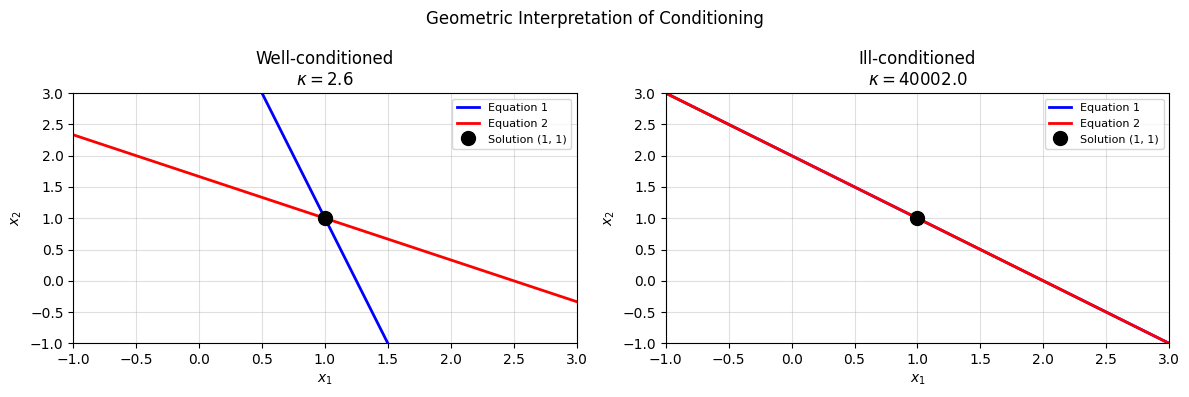

In [ ]:
# Condition numbers for various matrices
A_well = np.array([[4.0, 1.0], [2.0, 3.0]])
A_ill  = np.array([[1.0, 1.0], [1.0, 1.0001]])

print('Well-conditioned 2x2 matrix:')
print(f'  kappa_2   = {np.linalg.cond(A_well, 2):.2f}')
print(f'  kappa_1   = {np.linalg.cond(A_well, 1):.2f}')
print(f'  kappa_inf = {np.linalg.cond(A_well, np.inf):.2f}')

print('\nIll-conditioned 2x2 matrix (nearly singular rows):')
print(f'  kappa_2   = {np.linalg.cond(A_ill, 2):.2e}')
print(f'  Expected digits lost: ~{np.log10(np.linalg.cond(A_ill, 2)):.0f}')

# Geometric interpretation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_vec = np.linspace(-2, 4, 300)

for ax, (A, title) in zip(axes, [(A_well, 'Well-conditioned'), (A_ill, 'Ill-conditioned')]):
    # Two equations for each matrix with b = A @ [1, 1]^T
    b_ex = A @ np.array([1.0, 1.0]) # [1,1]^is the solution
    # Row 0: A[0,0]*x + A[0,1]*y = b[0]  =>  y = (b[0] - A[0,0]*x) / A[0,1]
    y0 = (b_ex[0] - A[0, 0] * x_vec) / A[0, 1]
    y1 = (b_ex[1] - A[1, 0] * x_vec) / A[1, 1]
    ax.plot(x_vec, y0, 'b-', lw=2, label='Equation 1')
    ax.plot(x_vec, y1, 'r-', lw=2, label='Equation 2')
    ax.plot(1, 1, 'ko', ms=10, zorder=5, label='Solution (1, 1)')
    ax.set(xlim=[-1, 3], ylim=[-1, 3], title=f'{title}\n$\\kappa = {np.linalg.cond(A):.1f}$',
           xlabel='$x_1$', ylabel='$x_2$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Geometric Interpretation of Conditioning', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 The Hilbert Matrix: A Classic Ill-Conditioned Example

The **Hilbert matrix** $H \in \mathbb{R}^{n\times n}$ has entries:
$$H_{ij} = \frac{1}{i + j - 1}, \quad i,j = 1, \ldots, n$$

It arises in polynomial approximation (normal equations for monomials $1, x, x^2, \ldots$).
Its condition number grows **exponentially** with $n$, making it a benchmark
for testing the robustness of linear solvers.

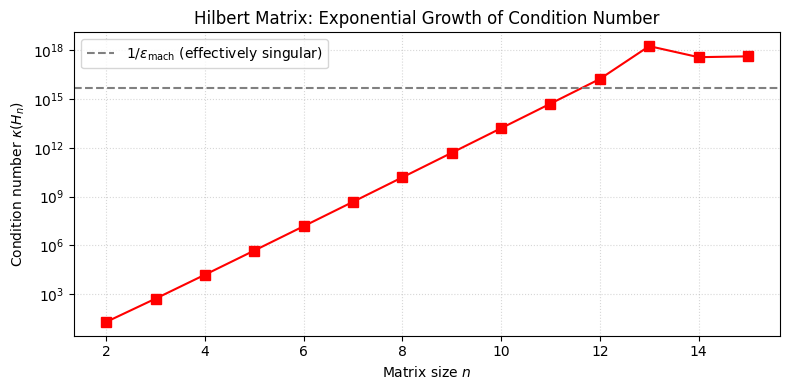


   n           kappa   digits lost
------------------------------------
   2        1.93e+01             1
   3        5.24e+02             2
   4        1.55e+04             4
   5        4.77e+05             5
   6        1.50e+07             7
   7        4.75e+08             8
   8        1.53e+10            10
   9        4.93e+11            11
  10        1.60e+13            13
  11        5.22e+14            14
  12        1.71e+16            16
  13        1.80e+18            16
  14        3.76e+17            16
  15        4.24e+17            16


In [28]:
# Hilbert matrix condition numbers
def hilbert(n):
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])

sizes_h = range(2, 16)
kappas  = [np.linalg.cond(hilbert(n)) for n in sizes_h]

plt.figure(figsize=(8, 4))
plt.semilogy(list(sizes_h), kappas, 'rs-', ms=7)
plt.axhline(1 / np.finfo(float).eps, color='gray', ls='--', label=r'$1/\varepsilon_{\rm mach}$ (effectively singular)')
plt.xlabel('Matrix size $n$')
plt.ylabel('Condition number $\\kappa(H_n)$')
plt.title('Hilbert Matrix: Exponential Growth of Condition Number')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\n{"n":>4}  {"kappa":>14}  {"digits lost":>12}')
print('-' * 36)
for n, k in zip(sizes_h, kappas):
    lost = min(16, int(np.log10(k))) if k > 1 else 0
    print(f'{n:>4}  {k:>14.2e}  {lost:>12}')

In [29]:
# Error amplification: solving H x = b where x_true = ones
# Perturb b slightly and see how much x changes

rng = np.random.default_rng(0)
results = []

for n in [4, 8, 12]:
    H = hilbert(n)
    x_true = np.ones(n)
    b_exact = H @ x_true

    # Add a small perturbation to b (simulating measurement noise)
    delta_b = rng.standard_normal(n) * 1e-10
    x_perturbed = np.linalg.solve(H, b_exact + delta_b)

    rel_b_err = np.linalg.norm(delta_b) / np.linalg.norm(b_exact)
    rel_x_err = np.linalg.norm(x_perturbed - x_true) / np.linalg.norm(x_true)
    amplification = rel_x_err / rel_b_err

    results.append((n, np.linalg.cond(H), rel_b_err, rel_x_err, amplification))

print(f'{"n":>4}  {"kappa":>12}  {"rel |db|":>10}  {"rel |dx|":>12}  {"amplification":>14}')
print('-' * 60)
for n, kappa, rb, rx, amp in results:
    print(f'{n:>4}  {kappa:>12.2e}  {rb:>10.2e}  {rx:>12.2e}  {amp:>14.2e}')

   n         kappa    rel |db|      rel |dx|   amplification
------------------------------------------------------------
   4      1.55e+04    2.47e-11      2.59e-07        1.05e+04
   8      1.53e+10    5.66e-11      2.84e-02        5.03e+08
  12      1.71e+16    6.54e-11      3.22e+05        4.92e+15


### 5.4 Exercise: Diagnosing an Ill-Conditioned System

A structural engineer reports that two different programs give very different displacements
for the same frame stiffness problem. The matrix is given below. Diagnose the issue
using the condition number and suggest a remedy.

In [ ]:
# Suspicious stiffness matrix (values in N/m)
K_susp = np.array([
    [1e6,  1e6 - 1,       0],
    [1e6 - 1, 1e6,        0],
    [0,        0,      1e-2]
], dtype=float)

f_susp = np.array([1000.0, 1000.0, 0.001])

# --- COMPLETE ---
# 1. Compute the condition number
kappa =                                              # np.linalg.cond(K_susp)
# 2. Estimate how many significant digits are lost
digits_lost =                                        # int(np.log10(kappa))
# 3. Solve the system
x_susp =                                             # np.linalg.solve(K_susp, f_susp)
# --- COMPLETE ---

print(f'Condition number kappa = {kappa:.2e}')
print(f'Significant digits lost ≈ {digits_lost}')
print(f'Solution x = {x_susp}')
print(f'Residual ||Kx - f|| = {np.linalg.norm(K_susp @ x_susp - f_susp):.2e}')
print()
print('Diagnosis: The upper-left 2x2 block has nearly identical rows')
print('(rows differ by only 1 N/m out of 1e6), making the system near-singular.')
print('The solution in the first two DOFs is unreliable.')

Condition number kappa = 2.00e+08
Significant digits lost ≈ 8
Solution x = [0.0005 0.0005 0.1   ]
Residual ||Kx - f|| = 0.00e+00

Diagnosis: The upper-left 2x2 block has nearly identical rows
(rows differ by only 1 N/m out of 1e6), making the system near-singular.
The solution in the first two DOFs is unreliable.


<!-- SOLUTION
kappa       = np.linalg.cond(K_susp)
digits_lost = int(np.log10(kappa))
x_susp      = np.linalg.solve(K_susp, f_susp)
-->

---
## Summary

### Factorization Methods

| Method | Decomposition | Cost | Applicable to | SciPy / NumPy |
|--------|---------------|------|---------------|---------------|
| **LU (Doolittle)** | $A = LU$ | $O(n^3/3)$ | Any nonsingular $A$ | `sc.linalg.lu` |
| **LU with pivoting** | $PA = LU$ | $O(n^3/3)$ | Numerically stable | `sc.linalg.lu_factor` |
| **Cholesky** | $A = LL^T$ | $O(n^3/6)$ | SPD only | `sc.linalg.cholesky` |

### Key Formulas

| Concept | Formula |
|---------|--------|
| **Doolittle U** | $u_{kj} = a_{kj} - \sum_{m<k} \ell_{km}\,u_{mj}$ |
| **Doolittle L** | $\ell_{ik} = \left(a_{ik} - \sum_{m<k} \ell_{im}\,u_{mk}\right)/u_{kk}$ |
| **Forward sub** | $d_i = b_i - \sum_{j<i} \ell_{ij}\,d_j$ |
| **Backward sub** | $x_i = \left(d_i - \sum_{j>i} u_{ij}\,x_j\right)/u_{ii}$ |
| **Condition number** | $\kappa(A) = \|A\|\,\|A^{-1}\|$ |
| **Error bound** | $\|\delta\mathbf{x}\|/\|\mathbf{x}\| \leq \kappa(A)\,\|\delta\mathbf{b}\|/\|\mathbf{b}\|$ |

### Practical Guidelines

1. **Multiple RHS:** Factor once with `lu_factor`, solve repeatedly with `lu_solve`.
2. **SPD matrices:** Use Cholesky (`assume_a='pos'` in `scipy.linalg.solve`) for $2\times$ speedup.
3. **Never invert explicitly** for solving linear systems — use `np.linalg.solve` instead.
4. **Always check $\kappa(A)$** if results seem suspicious — a condition number near $10^{16}$ signals an unreliable solution.
5. **Residual check:** Compute $\mathbf{r} = A\mathbf{x} - \mathbf{b}$ to verify accuracy independently of $\kappa$.